103.4301408
103
97.10558814235443
96


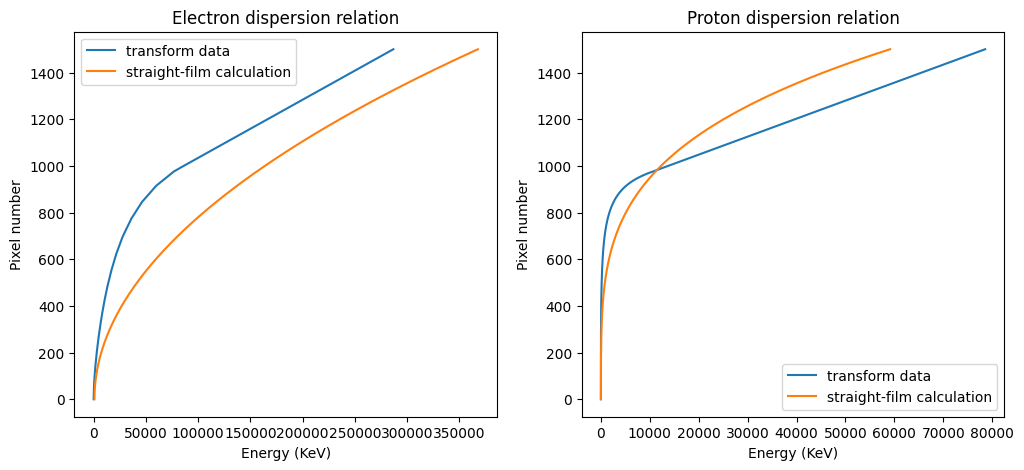

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

def lineout(array, w1, w2):
    width = np.shape(array)[0]
    length = np.shape(array)[1]
    line_data = array[w2,:]
    for i in range(length):
        line_data[i] = (1/(w2+1-w1))*np.sum(array[w1:w2+1,i])
    return line_data

def theoretical_dispersion(x,A,d):
    energy = A*(x**2+d**2)**2
    return energy

def theoretical_dispersion_relativistic_e(x,a,D):
    m = 9.1*10**-31
    c = 3*10**8
    E = m*c**2
    eV = 1.6*10**-19
    energy = (1/1000)*(1/eV)*0.5*(-E+np.sqrt(E**2+((eV*0.87*c)**2)*(1/D)*((((x-a)**2)+D)**2)))
    return energy

def theoretical_dispersion_relativistic_p(x,a,D):
    m = 1.67*10**-27
    c = 3*10**8
    E = m*c**2
    eV = 1.6*10**-19
    energy = (1/1000)*(1/eV)*0.5*(-E+np.sqrt(E**2+((eV*0.87*c)**2)*(1/D)*((((x-a)**2)+D)**2)))
    return energy

energy_data_protons = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows=1)
data_protons = np.loadtxt('Generated_Dispersion.txt', delimiter=',')
energy_data_electrons = np.loadtxt('NEPPS_Dispersion_Electrons_087T.txt', skiprows=1)

def linear_fit(x,m,c):
    y = m*x+c
    return y

def transform_electron_axis(x, R):
    energy = np.zeros(len(x))
    start = energy_data_electrons[-1,1]
    print(start)
    for i in range(len(x)):
        if np.abs((1/R)*x[i]-start) == np.min(np.abs((1/R)*x-start)):
            index = i
    print(index)
    energy[0:index] = np.interp((1/R)*x[0:index],np.array(energy_data_electrons[:,1]),np.array(energy_data_electrons[:,0]))

    deltax = energy_data_electrons[-1,1]-energy_data_electrons[-2,1]

    deltaE = energy_data_electrons[-1,0]-energy_data_electrons[-2,0]

    grad = deltaE/deltax

    intercept = energy_data_electrons[-1,0] - grad*energy_data_electrons[-1,1]

    energy[index:] = linear_fit((1/R)*x[index:], grad, intercept)

    return energy

def transform_proton_axis(x, R):
    energy = np.zeros(len(x))
    start = data_protons[1,-1]
    print(start)
    for i in range(len(x)):
        if np.abs((1/R)*x[i]-start) == np.min(np.abs((1/R)*x-start)):
            index = i
    print(index)
    energy[0:index] = np.interp((1/R)*x[0:index],np.array(data_protons[1]),np.array(data_protons[0]))

    deltax = data_protons[1,-1]-data_protons[1,-2]

    deltaE = data_protons[0,-1]-data_protons[0,-2]

    grad = deltaE/deltax

    intercept = data_protons[0,-1] - grad*data_protons[1,-1]

    energy[index:] = linear_fit((1/R)*x[index:], grad, intercept)

    return energy

def find_index(axis,start,end):
    for i in range(len(axis)):
        if np.abs(axis[i]-start) == np.min(np.abs(axis-start)):
            start_i = i

    for i in range(len(axis)):
        if np.abs(axis[i]-end) == np.min(np.abs(axis-end)):
            end_i = i
    return start_i, end_i


r = 10

x_axis = np.linspace(0,1500,150)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(transform_electron_axis(x_axis,10),x_axis,label='transform data')
axs[0].plot(theoretical_dispersion_relativistic_e((1/10000)*x_axis,0.0,0.008**2),x_axis,label='straight-film calculation')
axs[0].set_xlabel("Energy (KeV)")
#axs[0].set_xlim(0,500)
#axs[0].set_ylim(0,200)
axs[0].set_ylabel("Pixel number")
axs[0].set_title("Electron dispersion relation")
axs[0].legend()

axs[1].plot(transform_proton_axis(x_axis,10),x_axis,label='transform data')
axs[1].plot(theoretical_dispersion_relativistic_p((1/10000)*x_axis,0.001,0.012**2),x_axis,label='straight-film calculation')
axs[1].set_xlabel("Energy (KeV)")
axs[1].set_ylabel("Pixel number")
#axs[1].set_xlim(0,500)
#axs[1].set_ylim(0,600)
axs[1].set_title("Proton dispersion relation")
axs[1].legend()

ther_, pcov_ = curve_fit(theoretical_dispersion, energy_data_electrons[:,1], energy_data_electrons[:,0], p0=[0.0028,5])

energy = theoretical_dispersion((1/10)*x_axis, ther_[0], ther_[1])

#axs[0].plot(energy,x_axis)

97.10558814235443
96
97.10558814235443
96
97.10558814235443
96
97.10558814235443
96


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_25505/1187123461.py:30: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(np.array([0, 125, 250, 375, 500, 717, 789]), np.array([0, 0, 0, 0, 0, 0.0204, 0.0784]), 8)


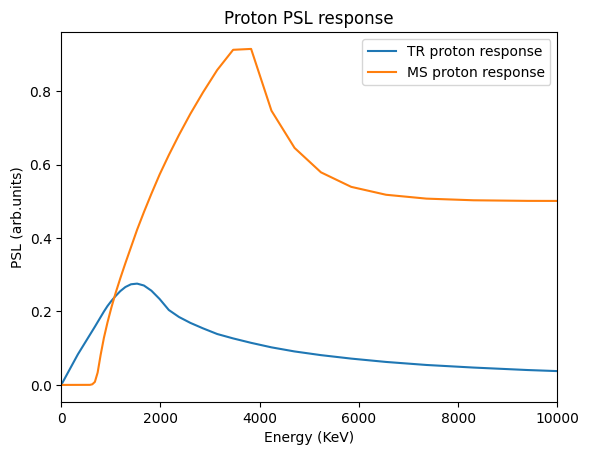

In [3]:
Proton_PSL_data = np.loadtxt('Proton_PSL_linylinx.txt', delimiter=',', skiprows=1)
Proton_PSL_data_low = np.loadtxt('Proton_PSL_low.txt', delimiter=',', skiprows=1)

TR_proton_energy_axis = 1000*Proton_PSL_data[:,0]
TR_proton_PSL_axis = Proton_PSL_data[:,1]

Proton_PSL_data = np.loadtxt('MS_Proton.txt', delimiter=',', skiprows=2)

MS_proton_energy_axis = 1000*Proton_PSL_data[:,0]
MS_proton_PSL_axis = Proton_PSL_data[:,1]

#plt.plot(TR_proton_energy_axis,TR_proton_PSL_axis)

#plt.plot(MS_proton_energy_axis,MS_proton_PSL_axis)

#plt.scatter(TR_proton_energy_axis,TR_proton_PSL_axis)

def find_exp_shift(E, A, a, shift):
    func = (A*np.exp(-a*E))+shift
    return func

def find_poly(E, A, a, shift):
    func = (A*E)**a+shift
    return func

def TR_proton_PSL_scale(Espace):
    PSL = np.interp(Espace,TR_proton_energy_axis,TR_proton_PSL_axis)
    return PSL

coefficients = np.polyfit(np.array([0, 125, 250, 375, 500, 717, 789]), np.array([0, 0, 0, 0, 0, 0.0204, 0.0784]), 8)

x = np.linspace(0,800,50)

poly_fit_MS = np.poly1d(coefficients)

#plt.plot(x,poly_fit_MS(x))

t_2, p_2 = curve_fit(find_exp_shift, np.linspace(4000,5000,100), np.interp(np.linspace(4000,5000,100),MS_proton_energy_axis,MS_proton_PSL_axis), p0=(1,0.0001,0.4))

fit_2 = find_exp_shift(np.linspace(4000,10000,100), t_2[0], t_2[1], t_2[2])

def MS_proton_PSL_scale(Espace):

    t_2, p_2 = curve_fit(find_exp_shift, np.linspace(4000,5000,100), np.interp(np.linspace(4000,5000,100),MS_proton_energy_axis,MS_proton_PSL_axis), p0=(1,0.0001,0.4))

    fit_2 = find_exp_shift(np.linspace(4000,10000,100), t_2[0], t_2[1], t_2[2])

    PSL = np.zeros(len(Espace))
    start = MS_proton_energy_axis[0]
    end = MS_proton_energy_axis[-1]
    
    for i in range(len(Espace)):
        if np.abs(Espace[i]-start) == np.min(np.abs(Espace-start)):
            start_index = i

    for i in range(len(Espace)):
        if np.abs(Espace[i]-end) == np.min(np.abs(Espace-end)):
            end_index = i

    PSL[start_index:end_index] = np.interp(Espace[start_index:end_index],MS_proton_energy_axis,MS_proton_PSL_axis)
    #PSL[:start_index] = MS_proton_PSL_axis[0]
    PSL[:start_index] = poly_fit_MS(Espace[:start_index])
    PSL[end_index:] = np.interp(Espace[end_index:],np.linspace(4000,10000,100),fit_2)

    return PSL

def find_exp(E, A, a):
    func = (A*np.exp(-a*E))
    return func

def find_2exp(E, A, a, B, b):
    func = func = ((A*np.exp(-a*E))+(B*np.exp(-b*E)))
    return func

def find_exp_proton(E, A, a, shift):
    func = (A*np.exp(-a*E))*TR_proton_PSL_scale(E)+shift
    return func

def find_2exp_proton(E, A, a, B, b, shift):
    func = ((A*np.exp(-a*E))+(B*np.exp(-b*E)))*TR_proton_PSL_scale(E)+shift
    return func

def find_temp(E, A, E0, kT):
    func = A*(1/np.sqrt(E))*np.exp((1/kT)*(np.sqrt(E)-np.sqrt(E0))**2)
    return func

##############################################################

energy_data_protons = np.loadtxt('NEPPS_Dispersion_Protons_087T.txt', skiprows=1)
energy_data_electrons = np.loadtxt('NEPPS_Dispersion_Electrons_087T.txt', skiprows=1)

def dxdE_electrons(x_in):
    x_d = np.array(energy_data_electrons[:,1])
    E_d = np.array(energy_data_electrons[:,0])
    dxde_data = np.gradient(x_d,E_d)
    dxde = np.interp(0.1*x_in,x_d,dxde_data)
    return dxde

def dxdE_protons(x_in):
    x_data = np.array(data_protons[1])
    E_data = np.array(data_protons[0])
    dxde_data = np.gradient(x_data,E_data)
    dxde = np.interp(0.1*x_in,x_data,dxde_data)
    return dxde

plt.plot(transform_proton_axis(x_axis,10), TR_proton_PSL_scale(transform_proton_axis(x_axis,10)), label = 'TR proton response')

plt.plot(transform_proton_axis(x_axis,10), MS_proton_PSL_scale(transform_proton_axis(x_axis,10)), label = 'MS proton response')

#plt.plot(np.linspace(4000,10000,100),find_exp_shift(np.linspace(4000,10000,100), t[0], t[1], t[2]))


#plt.plot(x, fit1)

plt.xlim(0,10000)
plt.xlabel("Energy (KeV)")
plt.ylabel("PSL (arb.units)")
plt.title("Proton PSL response")
plt.legend()

9959.185028548465


Text(0.5, 1.0, 'TR Electron PSL response')

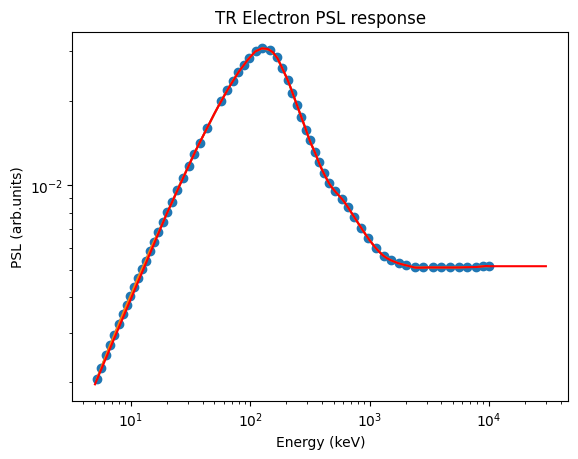

In [4]:
import numpy as np
from scipy.interpolate import CubicSpline

TR_signal_data = np.loadtxt('TR_Electron_Response.txt', delimiter=',', skiprows=1) # Adjust delimiter if needed
TR_energy_axis = 1000*TR_signal_data[:,0]
TR_PSL_axis = TR_signal_data[:,1]

plt.plot(TR_energy_axis,TR_PSL_axis)

print(TR_energy_axis[-1])

def TR_PSL_scale(Espace):
    func = CubicSpline(TR_energy_axis,TR_PSL_axis)
    PSL = []
    for E in Espace:
        if E <= TR_energy_axis[-1]:
            PSL_E = func(E)
        elif E > TR_energy_axis[-1]:
            PSL_E = TR_PSL_axis[-1]
        else:
            PSL_E = 0
        PSL.append(PSL_E)
    PSL = np.array(PSL)
    return PSL

# Assuming your text file is named 'data.txt' and contains a 2D array
energy_data = np.loadtxt('Electron_Dispersion_Z_vs_Ebeam_0028T.txt', skiprows=8) # Adjust delimiter if needed

TR_PSL_scale([1])

Espace = 1000*np.linspace(0.005,30,2000)

plt.loglog(TR_energy_axis,TR_PSL_axis)
plt.loglog(Espace,TR_PSL_scale(Espace),color = 'red')
plt.scatter(TR_energy_axis,TR_PSL_axis)
plt.xlabel("Energy (keV)")
plt.ylabel("PSL (arb.units)")
plt.title("TR Electron PSL response")
#plt.plot(transform_electron_axis(x_axis,10),MS_PSL_scale(transform_electron_axis(x_axis,10)))
#print(np.shape(energy_data[:,0]))
#print(np.shape(MS_energy_axis))
#plt.xlim([0,100000])
#print(np.shape(data))

59.70853527822819
45085.0698732236
Temperature in keV =  10
Bulk speed in c =  0.9998597420048027
2.0259230070576695e-23


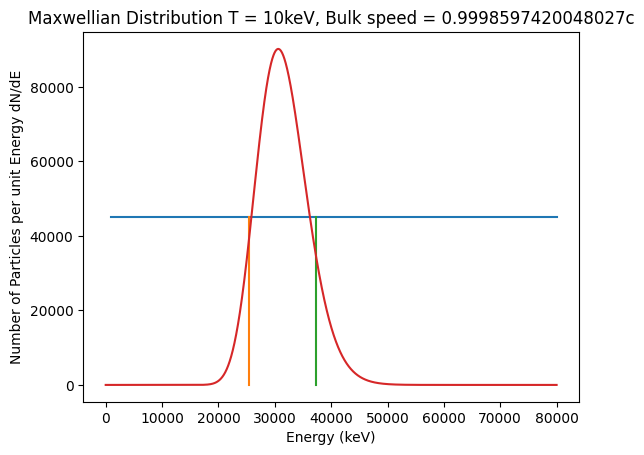

In [158]:
electron_mass = 9.1093837139e-31
light_speed = 299792458
electron_mass_energy = 512.4376
electron_mass_energy = 0.51099895069*1000

def p_(E, m = 9.11e-31):
    c = light_speed
    E_j = E*(1000*(1.60217663e-19))
    p = (1/c)*np.sqrt((E_j**2)-((m**2)*(c**4)))
    return p

def gamma(beta):
    gma = 1/(np.sqrt(1-(beta**2)))
    return gma

def Ep_prime(E,beta, particle = 'electron'):
    c = light_speed
    E_j = E*1000*(1.60217663e-19)
    if particle == 'electron':
        m = electron_mass
    elif particle == 'proton':
        m = 1.67262192e-27
    p = p_(E, m)
    gma = gamma(beta)
    E_prime = gma*(E_j-(beta*c*p))
    p_prime = gma*(p-((beta*E_j)/c))
    return E_prime, p_prime

ratio = 1836.4431104

def rel_maxwell(E, kT, beta, A, particle = 'electron'):
    c = light_speed
    gma = gamma(beta)
    E_j = E*(1000*(1.60217663e-19))
    if particle == 'electron':
        mass_energy = electron_mass_energy*(1000*(1.60217663e-19))
    elif particle == 'proton':
        mass_energy = ratio*electron_mass_energy*(1000*(1.60217663e-19))
    else:
        mass_energy = ratio*electron_mass_energy*(1000*(1.60217663e-19))
    if particle == 'electron':
        E_prime, p_prime = Ep_prime(E,beta)
        p = p_(E)
    elif particle == 'proton':
        E_prime, p_prime = Ep_prime(E,beta,particle = 'proton')
        p = p_(E, m = 1.67262192e-27)
    else:
        E_prime, p_prime = Ep_prime(E,beta,particle = 'proton')
        p = p_(E, m = 1.67262192e-27)
    #dist = np.exp(-(E_prime/(kT*1000*1.6e-19)))*gma*(1-((beta*p*c)/E_j))*(E_j/(p*c**2))
    ekt = ((E_prime-mass_energy)/(kT*1000*1.6e-19))
    dist = np.exp(-ekt)*gma*(E_j*p/c-((beta*p**2)))
    area = np.trapz(dist,E)
    #area = 1
    dist_renormal = A*dist/area
    return dist_renormal

E = np.linspace(0,80000,80000)


T = 10
bulk_KE = 30000
Amplitude = 1e9
gamma_ke = ((bulk_KE + electron_mass_energy)*1000*1.60217663e-19)/(electron_mass*(light_speed**2))
print(gamma_ke)
Bulk_Speed = np.sqrt(1-((1/gamma_ke)**2))

dist = rel_maxwell((E+511.034),T,Bulk_Speed,Amplitude, particle = 'electron')
mass_renorm = 511.034

print(np.max(dist)/2)

plt.plot([1e3,8e4], [np.max(dist)/2,np.max(dist)/2])
#plt.plot(25800*np.array([1,1]), [0,np.max(dist)/2])
#plt.plot(36200*np.array([1,1]), [0,np.max(dist)/2])

plt.plot(25500*np.array([1,1]), [0,np.max(dist)/2])
plt.plot(37300*np.array([1,1]), [0,np.max(dist)/2])

plt.plot(E,dist)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of Particles per unit Energy dN/dE")
plt.title('Maxwellian Distribution T = '+str(T)+'keV, Bulk speed = '+str(Bulk_Speed)+'c')

print('Temperature in keV = ', T)
print('Bulk speed in c = ', Bulk_Speed)
print(p_(512.4376))

Spectrometer Initialized!


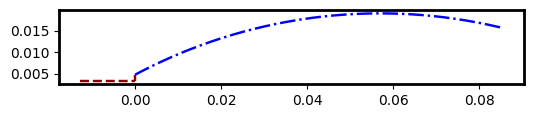

In [6]:
##Cell for finding very accurate dispersion relation##

#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec(charge_mass_ratio=1.75882000838e11)

# Spec.IP_radius = 0.1210056,
# Spec.IP_center = np.array([0.0570103,-0.1020064])

Spec.curved_IP(np.array([0.0570103,-0.1020064]),0.1210056)

Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 16)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.00005

fig, ax = Spec.plotIP()
ax.set_aspect('equal')

In [7]:
##finding EXDispersion##

#Espace_big = np.concatenate(((np.linspace(1000**(1/3),101250**(1/3),35))**3,np.linspace(111250, 100001250, 10001-11)))
#Xspace_big = Spec.EXdispersion(Espace_big, y_0 = 0, theta_0 = 0, track_termination=True)

Espace_big = np.linspace(22000,1e8,900)
Xspace_big = Spec.EXdispersion(Espace_big, y_0 = 0, theta_0 = 0, track_termination=True)

np.save('Espace_big_electrons', Espace_big)
np.save('Xspace_big_electrons', Xspace_big)
plt.plot(Espace_big,Xspace_big)

KeyboardInterrupt: 

12.745052819379275


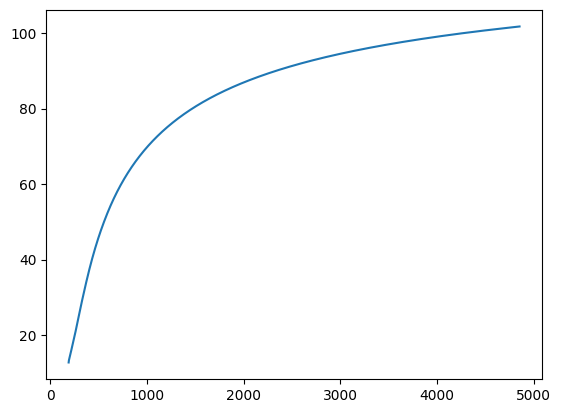

In [8]:
def xfromE(E):
    Espace_big = np.load('Espace_big_electrons.npy')
    Xspace_big = np.load('Xspace_big_electrons.npy')
    X = np.interp(E, Espace_big, Xspace_big)
    return X

Espace_big = np.load('Espace_big_electrons.npy')
Xspace_big = np.load('Xspace_big_electrons.npy')

Espace_big = Espace_big[12:]
Xspace_big = Xspace_big[12:]

energy_data_electrons = np.loadtxt('NEPPS_Dispersion_Electrons_087T.txt', skiprows=1)
espace_comsol = energy_data_electrons[:,0]
xspace_comsol = energy_data_electrons[:,1]

#plt.plot(Espace_big/1000,1000*Xspace_big)
#plt.plot(espace_comsol,xspace_comsol)

#print()

xfromE(101250)

espacegrad = Espace_big/1000
xspacegrad = 1000*Xspace_big
print(xspacegrad[0])

plt.plot((1/np.gradient(xspacegrad,espacegrad)),xspacegrad)
#plt.plot([0,500],[1000*xfromE(200000),1000*xfromE(200000)])


Spectrometer Initialized!


(-0.005, 0.015)

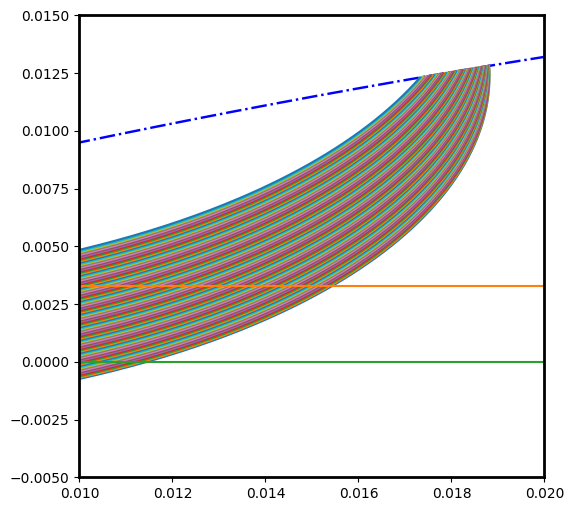

In [131]:
##initializing MagSpec and relevant functions##

#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

NEPPS_Field = (88.6/79)*np.loadtxt('Magnetic_Field_NEPPS.txt', skiprows=1)
Baxes, Bdata = NEPPS_Field[:,0], NEPPS_Field[:,1]
Spec = MagSpec.MagSpec(charge_mass_ratio=1.75882000838e11)
Spec.curved_IP(np.array([0.0570103,-0.1020064]),0.1210056)
Spec.mag_field(Baxes,Bdata)
Spec.fineadjustment(fine_adjustment = 8)
Spec.TCC(-0.2,0,0)
Spec.delta_d = 0.0001
#>>end of initialization

def Efromx(x):
    Espace_big = np.load('Espace_big_electrons.npy')
    Xspace_big = np.load('Xspace_big_electrons.npy')
    E = np.interp(x, Xspace_big, Espace_big)
    return E

def xfromE(E):
    Espace_big = np.load('Espace_big_electrons.npy')
    Xspace_big = np.load('Xspace_big_electrons.npy')
    X = np.interp(E, Espace_big, Xspace_big)
    return X

def dxdE_x(x):
    Espace_big = np.load('Espace_big_electrons.npy')
    Xspace_big = np.load('Xspace_big_electrons.npy')
    dxdE = np.gradient(Xspace_big,Espace_big)
    dxdE_interp = np.interp(x, Xspace_big, dxdE)
    return dxdE_interp

x_axis_params = [0,0.09,900]
x_axis = np.linspace(x_axis_params[0],x_axis_params[1],x_axis_params[2])
x_spacing = (x_axis_params[1]-x_axis_params[0])/(x_axis_params[2]-1)
E_axis = Efromx(x_axis)

fine_splitting = 24
modified_x_axis = np.linspace(x_axis_params[0],x_axis_params[1],(fine_splitting*(x_axis_params[2]-1))+1)
modified_E_axis = Efromx(modified_x_axis)

Spec.plotIP()

IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
            plotting = True,
            Energy_eV = 3000000,
            source = 'point',
            Range = np.linspace(-0.0125,0.0125,101),
            #Range = np.linspace(-0.0001,0.0001,11), 
            theta_z = 0,
            theta_0 = 0,
            setaxes=False)

plt.plot([-0.02,0.02],[0.0033,0.0033])
plt.plot([-0.02,0.02],[0.00,0.00])

#print(len(IP_dist_val))
#print(IP_dist_val)

plt.xlim(-0.01,0.01)
plt.ylim(-0.005,0.015)

plt.xlim(0.01,0.02)
plt.ylim(-0.005,0.015)

# plt.xlim(-0.01,0.05)
# plt.ylim(-0.005,0.055)

2.0019589996243936
0.8663077001157206


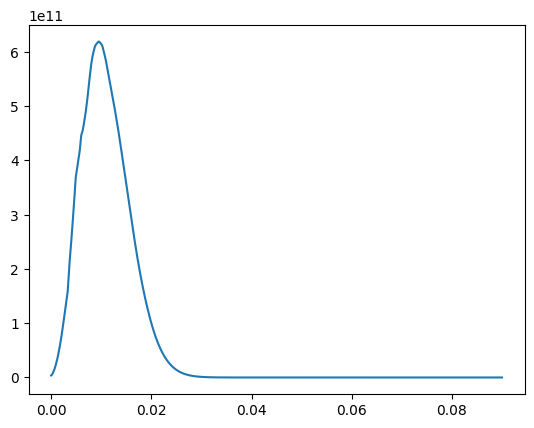

In [10]:
T = 128
bulk_KE = 512
Amplitude = 1e9
gamma_ke = ((bulk_KE + electron_mass_energy)*1000*1.60217663e-19)/(electron_mass*(light_speed**2))
print(gamma_ke)
Bulk_Speed = np.sqrt(1-((1/gamma_ke)**2))
print(Bulk_Speed)
#Bulk_Speed = 0.001 #in c

##Inputting maxwellian parameters into forward model, multiplying by scaling factors##

dNdE = rel_maxwell(((E_axis/1000)+electron_mass_energy),T,Bulk_Speed,Amplitude, particle = 'electron')
dSdN = TR_PSL_scale(E_axis/1000)

dSdE = dNdE*dSdN
dSdx = dSdE/dxdE_x(x_axis)

#plt.plot(x_axis,1/dxdE_x(x_axis))
plt.plot(x_axis,dSdx)

In [11]:
i = 0
i = 0
print(Espace_big[i])
print(Xspace_big[i])

1356522.8031145716
0.012745052819379274


In [12]:
##finding dispersions for each incident particle on slit##

multi_dispersion_array = []

for k in range(len(modified_x_axis)):
    x_position = modified_x_axis[k]
    Energy = modified_E_axis[k]

    IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
            plotting = False,
            Energy_eV = Energy,
            source = 'point',
            Range = np.linspace(-0.0125,0.0125,101), 
            theta_z = 0,
            theta_0 = 0)
    
    multi_dispersion_array.append(IP_dist_val)
    if k%1800==0:
        print('index k is currently: '+str(k))

multi_dispersion_array = np.array(multi_dispersion_array)
print(np.shape(multi_dispersion_array))
np.save('multi_dispersion_array_electrons',multi_dispersion_array)

index k is currently: 0
index k is currently: 1800
index k is currently: 3600
index k is currently: 5400
index k is currently: 7200
index k is currently: 9000
index k is currently: 10800
index k is currently: 12600
index k is currently: 14400
index k is currently: 16200
index k is currently: 18000
index k is currently: 19800
(21577, 101)


In [122]:
##Initializing variables for maxwellian electron distribution##

T = 64
bulk_KE = 1024
Amplitude = 1e9
gamma_ke = ((bulk_KE + electron_mass_energy)*1000*1.60217663e-19)/(electron_mass*(light_speed**2))
print(gamma_ke)
Bulk_Speed = np.sqrt(1-((1/gamma_ke)**2))
print(Bulk_Speed)
#Bulk_Speed = 0.001 #in c

##Inputting maxwellian parameters into forward model, multiplying by scaling factors##

dNdE = rel_maxwell(((E_axis/1000)+electron_mass_energy),T,Bulk_Speed,Amplitude, particle = 'electron')
dSdN = TR_PSL_scale(E_axis/1000)

dSdE = dNdE*dSdN
dSdx = dSdE/dxdE_x(x_axis)

##Convolving slit function with forward model##

slit_function_list = []
slit_sum_list = []
dSdx_ = np.zeros(len(dSdx))
multi_dispersion_array = np.load('multi_dispersion_array_electrons.npy')

for k in range(len(modified_x_axis)):
    x_position = modified_x_axis[k]
    Energy = modified_E_axis[k]

    IP_dist_values = multi_dispersion_array[k]

    interpolated_IP_dist_val = []
    amplify_number = 1
    particle_number_linspace = np.linspace(0,len(IP_dist_val)-1,len(IP_dist_val))
    fine_particle_number_linspace = np.linspace(0,amplify_number*(len(IP_dist_val)-1),(amplify_number*(len(IP_dist_val)-1))+1)
    IP_dist_function = spint.CubicSpline(particle_number_linspace,IP_dist_values)

    for i in range(len(fine_particle_number_linspace)):
         particle_number = fine_particle_number_linspace[i]
         interpolated_IP_dist_val.append(IP_dist_function(particle_number))

    slit_function_full_axis = np.zeros(len(x_axis))

    for i in range(len(x_axis)):
        if np.min(IP_dist_values)-0.5*x_spacing < x_axis[i] < np.max(IP_dist_values)+0.5*x_spacing:
            IP_dist_a = np.array(interpolated_IP_dist_val)[np.where(np.array(interpolated_IP_dist_val)<(x_axis[i]+0.5*x_spacing))]
            IP_dist_b = IP_dist_a[np.where(np.array(IP_dist_a)>(x_axis[i]-0.5*x_spacing))]
            slit_function_full_axis[i] = len(IP_dist_b)

    slit_function_norm = (1/fine_splitting)*slit_function_full_axis/101

    if k%1800==0:
            print('index k is currently: '+str(k))
    slit_function_list.append(slit_function_norm)
    dSdx_ = dSdx_ + np.interp(Energy,E_axis,dSdx)*slit_function_norm

np.save('ideal_spectra_T='+str(T)+'keV_KE='+str(bulk_KE)+'Amplitude='+str(Amplitude)+'electrons',dSdx)
np.save('convolved_spectra_T='+str(T)+'keV_KE='+str(bulk_KE)+'Amplitude='+str(Amplitude)+'electrons',dSdx_)


3.0039180017488225
0.942962641721944
index k is currently: 0
index k is currently: 1800
index k is currently: 3600
index k is currently: 5400
index k is currently: 7200
index k is currently: 9000
index k is currently: 10800
index k is currently: 12600
index k is currently: 14400
index k is currently: 16200
index k is currently: 18000
index k is currently: 19800


/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_25505/1137138092.py:49: OptimizeWarning: Covariance of the parameters could not be estimated
  dSdx_fitted_guess_params, param_cov = curve_fit(f=fitting_function,xdata=x_axis,ydata=dSdx_,p0=[T,bulk_KE,Amplitude])#bounds=([80,80,6e8],[250,250,1.4e9]))


[6.24657910e+01 1.02400000e+03 9.87437314e+08]
587711164.5320585
1.090858145471445


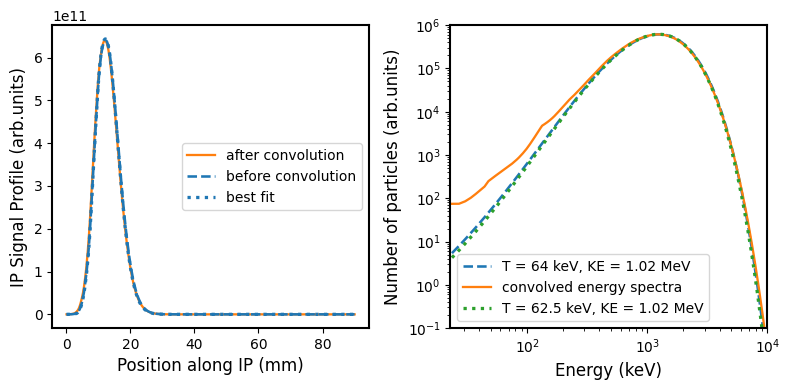

In [125]:
##derived energy spectra without deconvolution##

from scipy.signal import savgol_filter as sfilter
from scipy.optimize import curve_fit

T = 64
bulk_KE = 1024
Amplitude = 1e9

##loading case##
dNdE = rel_maxwell(((E_axis/1000)+(electron_mass_energy)),T,Bulk_Speed,Amplitude, particle = 'electron')
dSdx = np.load('ideal_spectra_T='+str(T)+'keV_KE='+str(bulk_KE)+'Amplitude='+str(Amplitude)+'electrons'+'.npy')
dSdx_ = np.load('convolved_spectra_T='+str(T)+'keV_KE='+str(bulk_KE)+'Amplitude='+str(Amplitude)+'electrons'+'.npy')
dSdN = TR_PSL_scale(E_axis/1000)

dSdE_ = dSdx_*dxdE_x(x_axis)
dNdE_ = dSdE_/dSdN

dSdx_smoothed = sfilter(dSdx_,16,3)
dSdE_smoothed = dSdx_smoothed*dxdE_x(x_axis)
dNdE_smoothed = dSdE_smoothed/dSdN

##guess parameters for convolved plot##

# ##case 1##
# T = 6.8 #in keV
# bulk_KE = 8 #in keV
# Bulk_Speed = np.sqrt((2*bulk_KE*1000*1.602e-19)/(1.6726e-27))/(2.99792e8)
# print(Bulk_Speed)
# Amplitude = 0.91e9 #arbitrary

##Inputting guessed maxwellian parameters into forward model, multiplying by scaling factors##
dNdE_guess = rel_maxwell(((E_axis/1000)+(electron_mass_energy)),T,Bulk_Speed,Amplitude, particle = 'electron')
dSdN = TR_PSL_scale(E_axis/1000)

dSdE_guess = dNdE_guess*dSdN
dSdx_guess = dSdE_guess/dxdE_x(x_axis)

def fitting_function(x_axis,Temperature,KE,Amp):
    E_axis = Efromx(x_axis)
    gamma_ke = ((bulk_KE + electron_mass_energy)*1000*1.60217663e-19)/(electron_mass*(light_speed**2))
    Speed = np.sqrt(1-((1/gamma_ke)**2))
    dNdE_guess_fit = rel_maxwell(((E_axis/1000)+(electron_mass_energy)),Temperature,Speed,Amp, particle = 'electron')
    dSdN_input = TR_PSL_scale(E_axis/1000)
    dSdE_guess_fit = dNdE_guess_fit*dSdN_input
    dSdx_guess_fit = dSdE_guess_fit/dxdE_x(x_axis)
    return dSdx_guess_fit

dSdx_fitted_guess_params, param_cov = curve_fit(f=fitting_function,xdata=x_axis,ydata=dSdx_,p0=[T,bulk_KE,Amplitude])#bounds=([80,80,6e8],[250,250,1.4e9]))
print(dSdx_fitted_guess_params)
dSdx_fitted_guess = fitting_function(x_axis,dSdx_fitted_guess_params[0],dSdx_fitted_guess_params[1],dSdx_fitted_guess_params[2])
T_guess = dSdx_fitted_guess_params[0]
Bulk_KE_guess = dSdx_fitted_guess_params[1]
gamma_ke_guess = ((Bulk_KE_guess + electron_mass_energy)*1000*1.60217663e-19)/(electron_mass*(light_speed**2))
Bulk_Speed_guess = np.sqrt(1-((1/gamma_ke)**2))
Amplitude_guess = dSdx_fitted_guess_params[2]

dNdE_fitted_guess = rel_maxwell(((E_axis/1000)+electron_mass_energy),T_guess,Bulk_Speed_guess,Amplitude_guess, particle = 'electron')


#checking error bounds
percenterror = 5

extra_dNdE = rel_maxwell(((E_axis/1000)+(electron_mass_energy)),T_guess,Bulk_Speed_guess*(1+percenterror/100),Amplitude_guess*(1-3/100), particle = 'electron')
extra_dSdE = extra_dNdE*dSdN
extra_dSdx = extra_dSdE/dxdE_x(x_axis)

##plotting outputs for convolved image##

#fig, axs = plt.subplots(2, 1, figsize=(5.5, 8.25))
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].plot(x_axis[1:]*1e3, dSdx_smoothed[1:], label = 'after convolution', linewidth = 1.65, color = 'C1')
axs[0].plot(x_axis[1:]*1e3, dSdx[1:], linestyle = '--', label = 'before convolution', linewidth = 1.85, color = 'C0')
axs[0].plot(x_axis[1:]*1e3, dSdx_fitted_guess[1:],linestyle = ':', label = 'best fit', linewidth = 2.35)

#axs[0].plot(x_axis[81:]*1e3, extra_dSdx[81:], linestyle = '-.', label = 'extra', linewidth = 1.85)

axs[0].set_xlabel('Position along IP (mm)', fontsize = 12)
axs[0].set_ylabel('IP Signal Profile (arb.units)', fontsize = 12)
#axs[0].legend()
axs[0].legend(loc = 7)#128 128
# axs[0].legend(loc = 1)#6 8
# axs[0].legend(loc = 6)#8 256

axs[1].loglog(E_axis[1:]*1e-3, dNdE[1:], linestyle = '--', label = 'T = '+str(T)+' keV, KE = '+f"{bulk_KE/1000:.3g}"+' MeV', linewidth = 1.85)
axs[1].loglog(E_axis[1:]*1e-3, dNdE_smoothed[1:], label = 'convolved energy spectra', linewidth = 1.65)
axs[1].loglog(E_axis[1:]*1e-3, dNdE_fitted_guess[1:], linestyle = ':', label = 'T = '+f"{T_guess:.3g}"+' keV, KE = '+f"{Bulk_KE_guess/1000:.3g}"+' MeV', linewidth = 2.35)


axs[1].set_ylim(1e-1,1e6) #128 128
axs[1].set_xlim(2.3e4*1e-3,1e7*1e-3) #128 128

# axs[1].set_ylim(1e-2,5e5) #128 128
# axs[1].set_xlim(1e7*1e-3,6e7*1e-3) #128 128

axs[1].set_ylabel('Number of particles (arb.units)', fontsize = 12)
axs[1].set_xlabel('Energy (keV)', fontsize = 12)
axs[1].legend()

for location in ['left', 'right', 'top', 'bottom']:
    axs[0].spines[location].set_linewidth(1.5)
    axs[1].spines[location].set_linewidth(1.5)

fig.tight_layout()
print(E_axis[80]*1e3)
print(dNdE_smoothed[80]/dNdE[80])

# energy_in = 2.5e5
# fraction = (np.interp(energy_in,E_axis,dNdE_))/(np.interp(energy_in,E_axis,dNdE))
# print(fraction)

In [58]:
#plt.plot(E_axis[1:]*1e-3, dNdE_fitted_guess[1:])
test = rel_maxwell(((E_axis/1000)+electron_mass_energy),13.5,30000,9.6e8, particle = 'electron')
#print(dNdE_fitted_guess)
print(test)

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan na

/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_25505/3870756560.py:13: RuntimeWarning: invalid value encountered in sqrt
  gma = 1/(np.sqrt(1-(beta**2)))


22095.999325073404


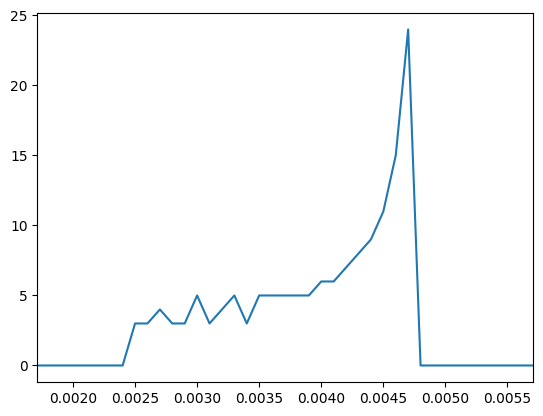

In [15]:
#>>initializing MagSpec
import matplotlib.ticker as ticker
import MagSpec
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as spint

x_axis_params = [0,0.09,900]
fine_splitting = 24
x_axis = np.linspace(x_axis_params[0],x_axis_params[1],x_axis_params[2])
x_spacing = (x_axis_params[1]-x_axis_params[0])/(x_axis_params[2]-1)
modified_x_axis = np.linspace(x_axis_params[0],x_axis_params[1],(fine_splitting*(x_axis_params[2]-1))+1)

E_axis = Efromx(x_axis)
modified_E_axis = Efromx(modified_x_axis)

Energy = 200000

IP_dist_val, X_data, Y_data, Z_data = Spec.track_1D_slit(
            plotting = False,
            Energy_eV = Energy,
            source = 'point',
            Range = np.linspace(-0.0125,0.0125,101), 
            theta_z = 0,
            theta_0 = 0)

interpolated_IP_dist_val = []
amplify_number = 24
particle_number_linspace = np.linspace(0,len(IP_dist_val)-1,len(IP_dist_val))
fine_particle_number_linspace = np.linspace(0,amplify_number*(len(IP_dist_val)-1),(amplify_number*(len(IP_dist_val)-1))+1)
IP_dist_function = spint.CubicSpline(particle_number_linspace,IP_dist_val)

#print(fine_particle_number_linspace)

for i in range(len(fine_particle_number_linspace)):
    particle_number = fine_particle_number_linspace[i]
    interpolated_IP_dist_val.append(IP_dist_function(particle_number))

slit_function_full_axis = np.zeros(len(x_axis))

for i in range(len(x_axis)):
    if np.min(IP_dist_val)-0.5*x_spacing < x_axis[i] < np.max(IP_dist_val)+0.5*x_spacing:
        IP_dist_a = np.array(interpolated_IP_dist_val)[np.where(np.array(interpolated_IP_dist_val)<(x_axis[i]+0.5*x_spacing))]
        IP_dist_b = IP_dist_a[np.where(np.array(IP_dist_a)>(x_axis[i]-0.5*x_spacing))]
        slit_function_full_axis[i] = len(IP_dist_b)

slit_function_norm = (1/fine_splitting)*slit_function_full_axis/np.sum(slit_function_full_axis)

plt.plot(x_axis,slit_function_full_axis)

plt.xlim(np.max(IP_dist_val)-0.003,np.max(IP_dist_val)+0.001)

print(modified_E_axis[13])